In [5]:
!pip install langgraph langchain langchain-google-genai google-generativeai

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from IPython.display import Image

In [7]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

gemini_model = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

## USE CASE 1: Telecom SIM Activation & Fraud Verification Workflow

### Step 1 — Define the SIM Application State

In [8]:
from typing import TypedDict

class SIMApplicationState(TypedDict):
    # Applicant details provided by the user
    applicant_name: str
    id_verification_status: str   # Expected values: 'VALID' or 'INVALID'
    supporting_doc_status: str    # Expected values: 'VALID' or 'INVALID'
    applicant_city: str
    prior_sim_count: int

    # Fields populated during workflow execution
    kyc_result: str
    risk_level: str
    activation_outcome: str

### Step 2 — KYC Validation Tool & Processing Node

In [9]:
@tool
def run_kyc_check(id_verification_status: str, supporting_doc_status: str) -> str:
    """Performs KYC validation by checking the applicant's ID and document authenticity."""
    if id_verification_status == 'VALID' and supporting_doc_status == 'VALID':
        return "VERIFIED"
    elif id_verification_status == 'INVALID' or supporting_doc_status == 'INVALID':
        return "INVALID_DOCUMENT"
    else:
        return "PENDING_VERIFICATION"


def kyc_validation_node(state: SIMApplicationState) -> SIMApplicationState:
    outcome = run_kyc_check.invoke({
        "id_verification_status": state["id_verification_status"],
        "supporting_doc_status": state["supporting_doc_status"]
    })
    state['kyc_result'] = outcome
    return state

### Step 3 — AI-Powered Fraud Risk Assessment Node

In [10]:
def fraud_risk_assessment_node(state: SIMApplicationState) -> SIMApplicationState:
    # If KYC failed, immediately classify as high risk without calling the LLM
    if state['kyc_result'] != 'VERIFIED':
        state['risk_level'] = 'HIGH_RISK'
        return state

    assessment_prompt = f"""
    Review the applicant details below and classify the fraud risk as one of:
    LOW_RISK, MEDIUM_RISK, or HIGH_RISK.
    Respond with exactly one classification and nothing else.

    Applicant Information:
    Name: {state['applicant_name']}
    KYC Status: {state['kyc_result']}
    City: {state['applicant_city']}
    Previous SIM Requests: {state['prior_sim_count']}

    Evaluation Criteria:
    - Failed KYC always results in HIGH_RISK (already handled before this step).
    - More than 5 prior SIM requests or atypical locations may elevate the risk.
    - A verified KYC is a positive signal, but other factors should still be weighed.
    """

    ai_response = gemini_model.invoke(assessment_prompt)
    state['risk_level'] = ai_response.content.strip()
    return state

### Step 4 — Activation Decision Tool & Output Node

In [11]:
@tool
def decide_sim_activation(risk_level: str) -> str:
    """Determines the SIM activation outcome based on the assessed risk level."""
    if risk_level == 'LOW_RISK':
        return "SIM Activated"
    elif risk_level == 'MEDIUM_RISK':
        return "Manual Review"
    else:
        return "Reject Application"


def activation_decision_node(state: SIMApplicationState) -> SIMApplicationState:
    result = decide_sim_activation.invoke({"risk_level": state['risk_level']})
    state['activation_outcome'] = result
    return state

### Step 5 — Assemble and Compile the SIM Workflow

In [12]:
sim_workflow_graph = StateGraph(SIMApplicationState)

# Register each processing node
sim_workflow_graph.add_node('kyc_validation', kyc_validation_node)
sim_workflow_graph.add_node('fraud_risk_assessment', fraud_risk_assessment_node)
sim_workflow_graph.add_node('activation_decision', activation_decision_node)

# Set the entry point
sim_workflow_graph.set_entry_point('kyc_validation')

# Connect nodes in sequence
sim_workflow_graph.add_edge(START, 'kyc_validation')
sim_workflow_graph.add_edge('kyc_validation', 'fraud_risk_assessment')
sim_workflow_graph.add_edge('fraud_risk_assessment', 'activation_decision')
sim_workflow_graph.add_edge('activation_decision', END)

sim_pipeline = sim_workflow_graph.compile()

print("SIM Activation Pipeline compiled successfully!")

SIM Activation Pipeline compiled successfully!


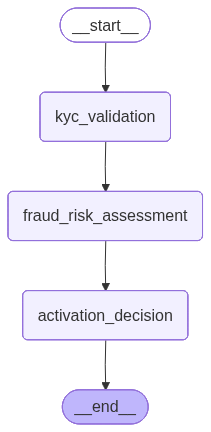

In [13]:
# Display the workflow graph
sim_pipeline

### Step 6 — Test the SIM Activation Workflow

In [31]:
# Test Case 1: Low-Risk Applicant
low_risk_applicant: SIMApplicationState = {
    "applicant_name": "Rajesh",
    "id_verification_status": "VALID",
    "supporting_doc_status": "VALID",
    "applicant_city": "chennai",
    "prior_sim_count": 1,
    "kyc_result": "",
    "risk_level": "",
    "activation_outcome": ""
}

low_risk_result = sim_pipeline.invoke(low_risk_applicant)
print("Outcome (Low Risk):", low_risk_result)

Outcome (Low Risk): {'applicant_name': 'Rajesh', 'id_verification_status': 'VALID', 'supporting_doc_status': 'VALID', 'applicant_city': 'chennai', 'prior_sim_count': 1, 'kyc_result': 'VERIFIED', 'risk_level': 'LOW_RISK', 'activation_outcome': 'SIM Activated'}


In [32]:
# Test Case 2: Medium-Risk Applicant
medium_risk_applicant: SIMApplicationState = {
    "applicant_name": "Jaideep",
    "id_verification_status": "VALID",
    "supporting_doc_status": "VALID",
    "applicant_city": "chithoor",
    "prior_sim_count": 3,
    "kyc_result": "",
    "risk_level": "",
    "activation_outcome": ""
}

medium_risk_result = sim_pipeline.invoke(medium_risk_applicant)
print("Outcome (Medium Risk):", medium_risk_result)

Outcome (Medium Risk): {'applicant_name': 'Jaideep', 'id_verification_status': 'VALID', 'supporting_doc_status': 'VALID', 'applicant_city': 'chithoor', 'prior_sim_count': 3, 'kyc_result': 'VERIFIED', 'risk_level': 'LOW_RISK', 'activation_outcome': 'SIM Activated'}


In [33]:
# Test Case 3: High-Risk Applicant (Invalid Documents)
invalid_docs_applicant: SIMApplicationState = {
    "applicant_name": "Rahul",
    "id_verification_status": "VALID",
    "supporting_doc_status": "INVALID",
    "applicant_city": "Andhra Pradesh",
    "prior_sim_count": 0,
    "kyc_result": "",
    "risk_level": "",
    "activation_outcome": ""
}

invalid_docs_result = sim_pipeline.invoke(invalid_docs_applicant)
print("Outcome (Invalid Docs):", invalid_docs_result)

Outcome (Invalid Docs): {'applicant_name': 'Rahul', 'id_verification_status': 'VALID', 'supporting_doc_status': 'INVALID', 'applicant_city': 'Andhra Pradesh', 'prior_sim_count': 0, 'kyc_result': 'INVALID_DOCUMENT', 'risk_level': 'HIGH_RISK', 'activation_outcome': 'Reject Application'}


In [27]:
# Test Case 4: High-Risk Applicant (Excessive Prior Requests)
high_requests_applicant: SIMApplicationState = {
    "applicant_name": "Raju",
    "id_verification_status": "VALID",
    "supporting_doc_status": "VALID",
    "applicant_city": "Hyderabad",
    "prior_sim_count": 15,
    "kyc_result": "",
    "risk_level": "",
    "activation_outcome": ""
}

high_requests_result = sim_pipeline.invoke(high_requests_applicant)
print("Outcome (High Requests):", high_requests_result)

Outcome (High Requests): {'applicant_name': 'Raju', 'id_verification_status': 'VALID', 'supporting_doc_status': 'VALID', 'applicant_city': 'Hyderabad', 'prior_sim_count': 15, 'kyc_result': 'VERIFIED', 'risk_level': 'MEDIUM_RISK', 'activation_outcome': 'Manual Review'}


## USE CASE 2: Healthcare Appointment Prioritization Workflow

### Step 1 — Define the Patient Triage State

In [18]:
from typing import TypedDict

class PatientTriageState(TypedDict):
    # Patient vitals and background provided as input
    body_temperature: float          # Degrees Fahrenheit
    spo2_reading: int                # Blood oxygen saturation (%)
    pulse_rate: int                  # Beats per minute
    hours_with_symptoms: int         # Duration of symptoms in hours
    age: int
    comorbidities: str               # e.g., 'None', 'Diabetes', 'Heart Disease'

    # Fields generated by the workflow
    triage_severity: str             # STABLE, MODERATE, or CRITICAL
    appointment_priority: str        # EMERGENCY, PRIORITY_CONSULTATION, or REGULAR_CONSULTATION
    assigned_care_type: str          # ICU/ER, Specialist Doctor, or General Physician

### Step 2 — Symptom Severity Evaluation Tool & Node

In [19]:
@tool
def evaluate_symptom_severity(body_temperature: float, spo2_reading: int, pulse_rate: int, hours_with_symptoms: int) -> str:
    """Evaluates patient vitals and returns a triage severity: STABLE, MODERATE, or CRITICAL."""
    severity = "STABLE"

    if body_temperature >= 102.0 or spo2_reading < 90 or pulse_rate > 120 or hours_with_symptoms > 48:
        severity = "CRITICAL"
    elif body_temperature >= 100.4 or spo2_reading < 94 or pulse_rate > 100 or hours_with_symptoms > 24:
        severity = "MODERATE"

    return severity


def symptom_evaluation_node(state: PatientTriageState) -> PatientTriageState:
    triage_result = evaluate_symptom_severity.invoke({
        "body_temperature": state["body_temperature"],
        "spo2_reading": state["spo2_reading"],
        "pulse_rate": state["pulse_rate"],
        "hours_with_symptoms": state["hours_with_symptoms"]
    })
    state['triage_severity'] = triage_result
    return state

### Step 3 — AI-Assisted Medical Priority Classification Node

In [20]:
def medical_priority_node(state: PatientTriageState) -> PatientTriageState:
    classification_prompt = f"""
    Using the patient details provided, determine the appropriate medical priority.
    Respond with exactly one of: EMERGENCY, PRIORITY_CONSULTATION, or REGULAR_CONSULTATION.
    Do not include any explanation or additional text.

    Patient Summary:
    Triage Severity: {state['triage_severity']}
    Patient Age: {state['age']}
    Pre-existing Conditions: {state['comorbidities']}

    Decision Guidelines:
    - CRITICAL severity always warrants EMERGENCY care.
    - Patients above 60 years with MODERATE severity or significant comorbidities lean toward PRIORITY_CONSULTATION.
    - STABLE patients with no risk factors are typically assigned REGULAR_CONSULTATION.
    """

    ai_response = gemini_model.invoke(classification_prompt)
    state['appointment_priority'] = ai_response.content.strip()
    return state

### Step 4 — Care Assignment Tool & Output Node

In [21]:
@tool
def assign_care_type(appointment_priority: str) -> str:
    """Maps the medical priority level to the appropriate care setting."""
    if appointment_priority == 'EMERGENCY':
        return "ICU/ER"
    elif appointment_priority == 'PRIORITY_CONSULTATION':
        return "Specialist Doctor"
    else:
        return "General Physician"


def care_assignment_node(state: PatientTriageState) -> PatientTriageState:
    care_type = assign_care_type.invoke({"appointment_priority": state['appointment_priority']})
    state['assigned_care_type'] = care_type
    return state

### Step 5 — Assemble and Compile the Healthcare Workflow

In [22]:
triage_workflow_graph = StateGraph(PatientTriageState)

# Register processing nodes
triage_workflow_graph.add_node('symptom_evaluation', symptom_evaluation_node)
triage_workflow_graph.add_node('medical_priority', medical_priority_node)
triage_workflow_graph.add_node('care_assignment', care_assignment_node)

# Set the entry point
triage_workflow_graph.set_entry_point('symptom_evaluation')

# Connect nodes sequentially
triage_workflow_graph.add_edge(START, 'symptom_evaluation')
triage_workflow_graph.add_edge('symptom_evaluation', 'medical_priority')
triage_workflow_graph.add_edge('medical_priority', 'care_assignment')
triage_workflow_graph.add_edge('care_assignment', END)

triage_pipeline = triage_workflow_graph.compile()

print("Healthcare Triage Pipeline compiled successfully!")

Healthcare Triage Pipeline compiled successfully!


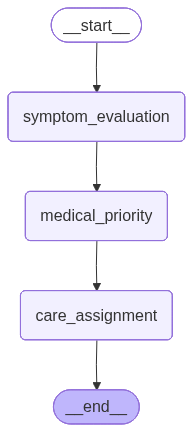

In [23]:
# Display the workflow graph
triage_pipeline

### Step 6 — Test the Healthcare Triage Workflow

In [28]:
# Test Case 1: Stable Patient
stable_patient: PatientTriageState = {
    "body_temperature": 97.4,
    "spo2_reading": 97,
    "pulse_rate": 76,
    "hours_with_symptoms": 3,
    "age": 32,
    "comorbidities": "None",
    "triage_severity": "",
    "appointment_priority": "",
    "assigned_care_type": ""
}

stable_result = triage_pipeline.invoke(stable_patient)
print("Triage Result (Stable):", stable_result)

Triage Result (Stable): {'body_temperature': 97.4, 'spo2_reading': 97, 'pulse_rate': 76, 'hours_with_symptoms': 3, 'age': 32, 'comorbidities': 'None', 'triage_severity': 'STABLE', 'appointment_priority': 'REGULAR_CONSULTATION', 'assigned_care_type': 'General Physician'}


In [29]:
# Test Case 2: Moderate Patient
moderate_patient: PatientTriageState = {
    "body_temperature": 101.8,
    "spo2_reading": 94,
    "pulse_rate": 103,
    "hours_with_symptoms": 28,
    "age": 59,
    "comorbidities": "Diabetes",
    "triage_severity": "",
    "appointment_priority": "",
    "assigned_care_type": ""
}

moderate_result = triage_pipeline.invoke(moderate_patient)
print("Triage Result (Moderate):", moderate_result)

Triage Result (Moderate): {'body_temperature': 101.8, 'spo2_reading': 94, 'pulse_rate': 103, 'hours_with_symptoms': 28, 'age': 59, 'comorbidities': 'Diabetes', 'triage_severity': 'MODERATE', 'appointment_priority': 'PRIORITY_CONSULTATION', 'assigned_care_type': 'Specialist Doctor'}


In [30]:
# Test Case 3: Critical Patient
critical_patient: PatientTriageState = {
    "body_temperature": 102.5,
    "spo2_reading": 86,
    "pulse_rate": 136,
    "hours_with_symptoms": 55,
    "age": 68,
    "comorbidities": "Heart Disease",
    "triage_severity": "",
    "appointment_priority": "",
    "assigned_care_type": ""
}

critical_result = triage_pipeline.invoke(critical_patient)
print("Triage Result (Critical):", critical_result)

Triage Result (Critical): {'body_temperature': 102.5, 'spo2_reading': 86, 'pulse_rate': 136, 'hours_with_symptoms': 55, 'age': 68, 'comorbidities': 'Heart Disease', 'triage_severity': 'CRITICAL', 'appointment_priority': 'EMERGENCY', 'assigned_care_type': 'ICU/ER'}
